In [1]:
from matplotlib import pyplot as plt
from whar_datasets.adapters.sampler import WHARSampler
from whar_datasets.support.getter import WHARDatasetID, get_whar_cfg

In [2]:
cfg = get_whar_cfg(WHARDatasetID.UCI_HAR)
sampler = WHARSampler(cfg, override_cache=False)

Creating config hash...
Checking download...
Download exists.
Checking sessions...
Sessions exist.
Validating common format...
[########################################] | 100% Completed | 740.26 ms
Common format validated.
Checking windowing...
Loading config hash...
Windowing exists.
subject_ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
activity_ids: [0 1 2 3 4 5]


In [3]:
sampler.prepare(scv_group_index=0)

Postprocessing...


Loading windows: 100%|██████████| 9499/9499 [00:07<00:00, 1265.76it/s]


Getting normalization parameters...
Loading config hash...
Creating normalization parameters hash...
Loading normalization parameters hash...


Caching samples: 100%|██████████| 9499/9499 [00:01<00:00, 5931.08it/s]


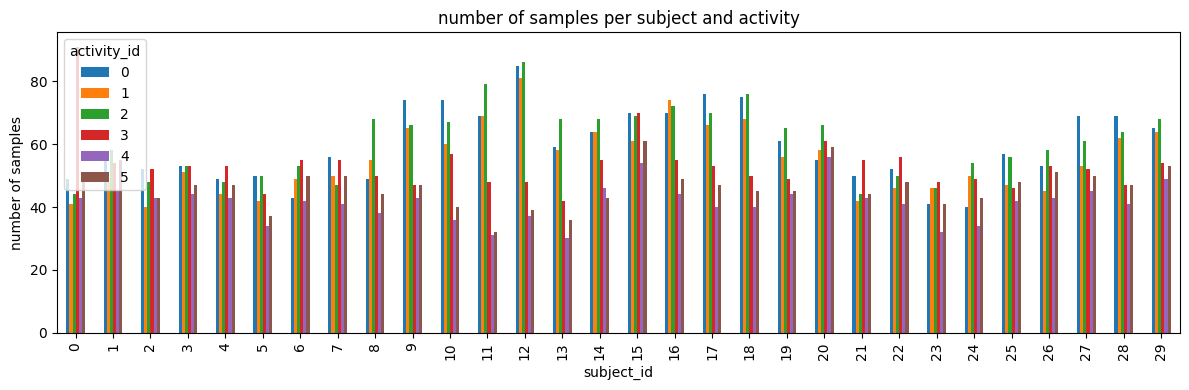

In [4]:
sampler.plot_indices_statistics(sampler.test_indices + sampler.train_indices)

torch.Size([5000, 384])
torch.Size([5000])


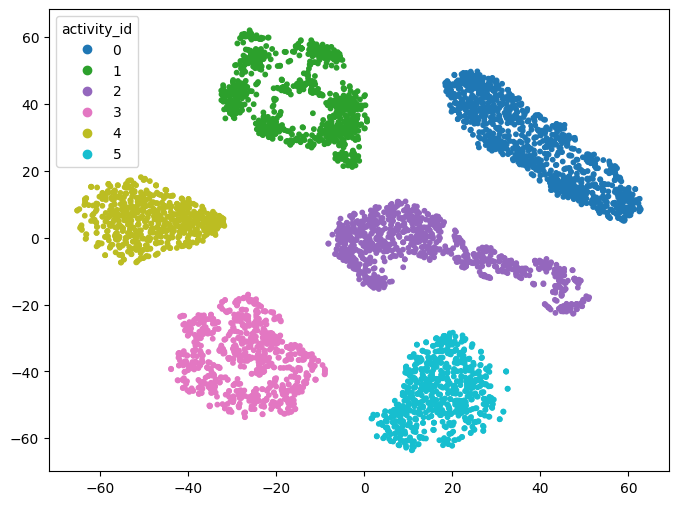

In [ ]:
import random
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
import umap
from flow_matching.whar.sampler import stft_transform_combine
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from flow_matching.whar.models.ae_cond import CondSpectrogramAE


ae = CondSpectrogramAE(latent_channels=24)
ae.load_state_dict(torch.load("models/cae_242.pt"))  #

y, x = sampler.sample(5000, sampler.test_indices + sampler.train_indices)
x = torch.stack([stft_transform_combine(xi) for xi in x])

x = ae.encode(x, y).detach()
x = x.view(x.shape[0], -1)

# x = StandardScaler().fit_transform(x)

# pca = PCA(n_components=50, random_state=42)
# x = pca.fit_transform(x)

print(x.shape)
print(y.shape)

seed = 42
random.seed(seed)
np.random.seed(seed)

# # Run UMAP
# reducer = umap.UMAP(
#     n_neighbors=30,
#     min_dist=0.1,
#     n_components=2,
#     random_state=seed,
#     metric="cosine",
# )

# X_umap = reducer.fit_transform(x)

tsne = TSNE(n_components=2, perplexity=30, random_state=seed, max_iter=1000)
X_tsne = tsne.fit_transform(x)

# Plot with subjects in different colors
plt.figure(figsize=(8, 6))

# scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap="tab10", s=10)
# plt.legend(*scatter.legend_elements(), title="activity_id")
# plt.show()

scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=10)
plt.legend(*scatter.legend_elements(), title="activity_id")
plt.show()

In [12]:
subset = sampler.window_metadata.iloc[sampler.test_indices]

# Merge with session_metadata to get subject_id info
merged = subset.merge(
    sampler.session_metadata[["session_id", "subject_id", "activity_id"]],
    on="session_id",
    how="left",
)

subject_ids = merged["subject_id"].unique().tolist()
print(subject_ids)
# subject_ids = subject_ids[:2]

print(merged.value_counts("activity_id"))

[0, 1, 2, 3, 4]
activity_id
3    303
0    260
2    251
5    241
1    224
4    218
Name: count, dtype: int64


In [13]:
import torch
from flow_matching.whar.ae_cond import CondSpectrogramAE


ae = CondSpectrogramAE(latent_channels=24)
ae.load_state_dict(torch.load("cond_ae_24.pt"))

<All keys matched successfully>

In [35]:
import numpy as np
from flow_matching.whar.sampler import stft_transform_combine
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

subject_map = {}

for sub in tqdm(subject_ids):
    y, x = sampler.sample(200, sampler.test_indices, subject_id=sub)
    x = torch.stack([stft_transform_combine(xi) for xi in x])

    # x = ae.encode(x, y)
    # x = x.detach()
    x = x.view(x.shape[0], -1)

    subject_map[sub] = x

X = torch.cat(list(subject_map.values()), dim=0)
y = np.array([sub for sub in subject_map.keys() for _ in range(200)])

X = StandardScaler().fit_transform(X)

print(X.shape)
print(y.shape)

100%|██████████| 5/5 [00:00<00:00,  9.01it/s]


(1000, 18432)
(1000,)


In [36]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

In [22]:
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)

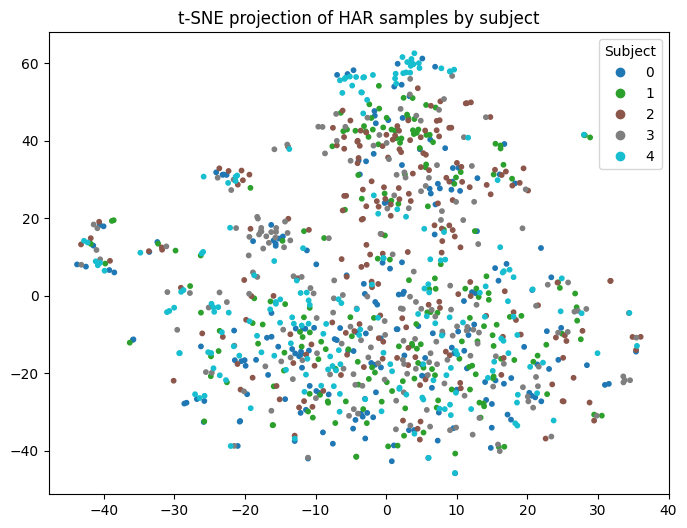

In [37]:
# --- Step 2: t-SNE ---
tsne = TSNE(n_components=2, perplexity=5, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X)

# --- Step 3: Plot ---
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=10)
plt.legend(*scatter.legend_elements(), title="Subject")
plt.title("t-SNE projection of HAR samples by subject")
plt.show()

/Users/maxburzer/flow-matching/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


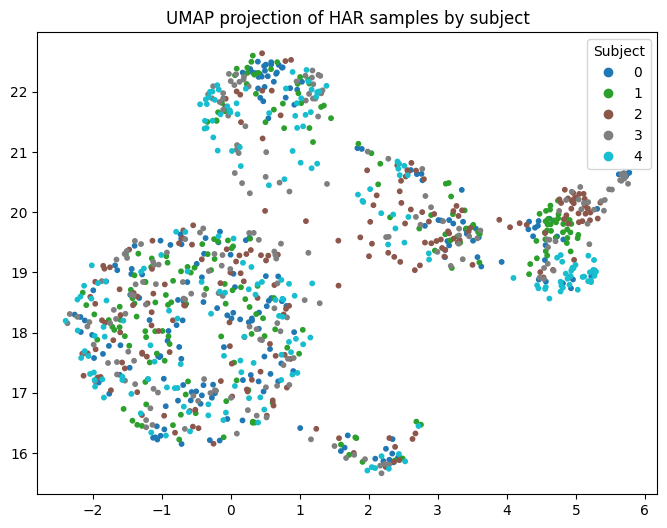

In [38]:
# Run UMAP
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=42,
    metric="cosine",
)

X_umap = reducer.fit_transform(X)

# Plot with subjects in different colors
plt.figure(figsize=(8, 6))

scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap="tab10", s=10)
plt.legend(*scatter.legend_elements(), title="Subject")
plt.title("UMAP projection of HAR samples by subject")
plt.show()